In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
import time
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 50, 'linewidths':0}


In [2]:
data = np.load('/content/cluster_data.npy')

In [3]:
data

array([[-0.12153499, -0.22876337],
       [-0.22093687, -0.25251088],
       [ 0.1259037 , -0.27314321],
       ...,
       [ 0.50243143, -0.3002958 ],
       [ 0.53822256,  0.19412199],
       [-0.08688887, -0.2092721 ]])

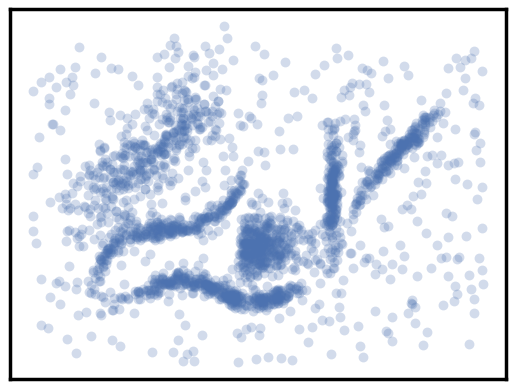

In [4]:
plt.scatter(data.T[0], data.T[1], c='b', **plot_kwds)
frame = plt.gca()
frame.axes.get_xaxis().set_visible(False)
frame.axes.get_yaxis().set_visible(False)


In [5]:
def plot_clusters(data, algorithm, args, kwds):
    start_time = time.time()
    labels = algorithm(*args, **kwds).fit_predict(data)
    end_time = time.time()
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters found by {}'.format(str(algorithm.__name__)), fontsize=12)
    plt.text(-0.2, 0.9, 'Clustering took {:.2f} s'.format(end_time - start_time), fontsize=14)


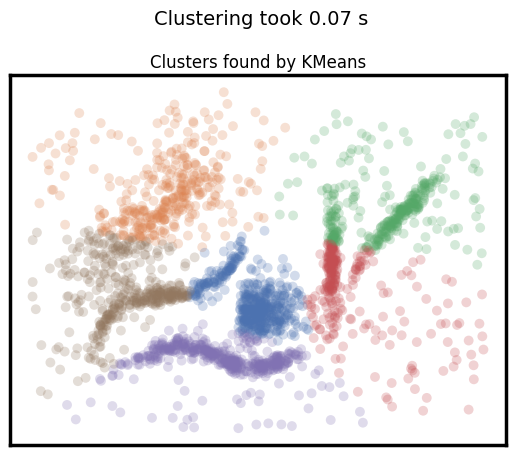

In [6]:

plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':10})

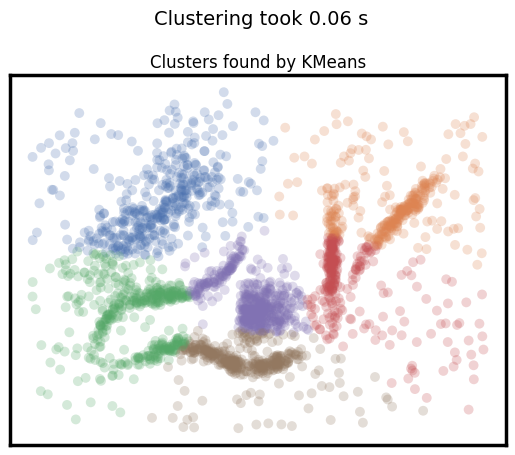

In [7]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':10, 'init':'random'})

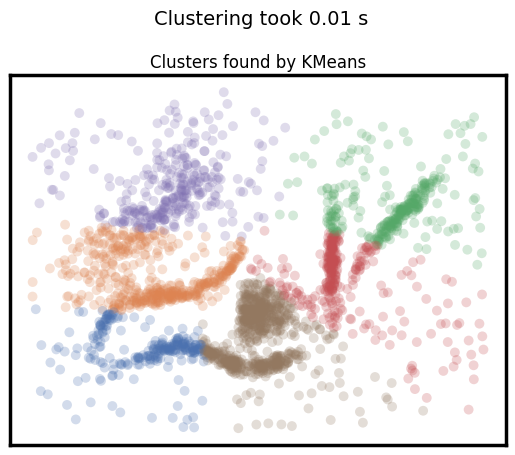

In [8]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':'auto'})

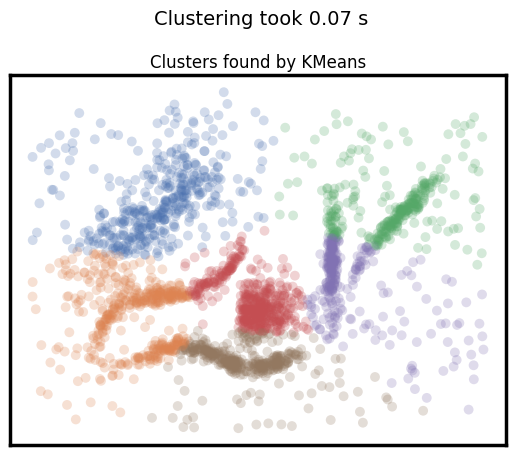

In [9]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':'auto', 'init':'random'})

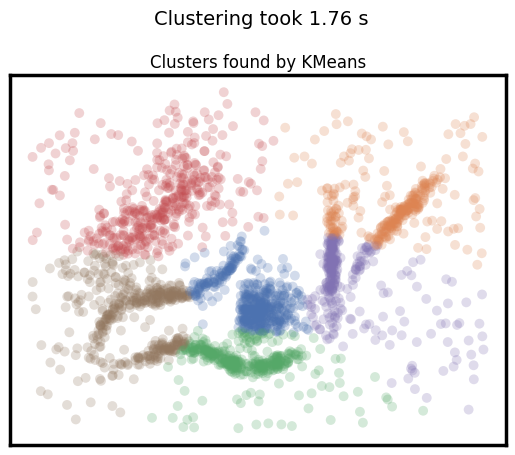

In [10]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':30})

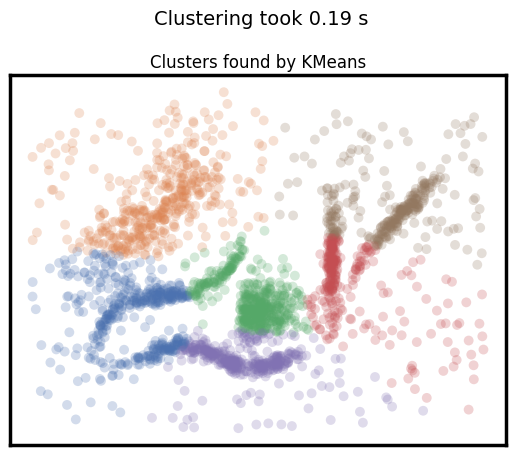

In [11]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':30, 'init':'random'})

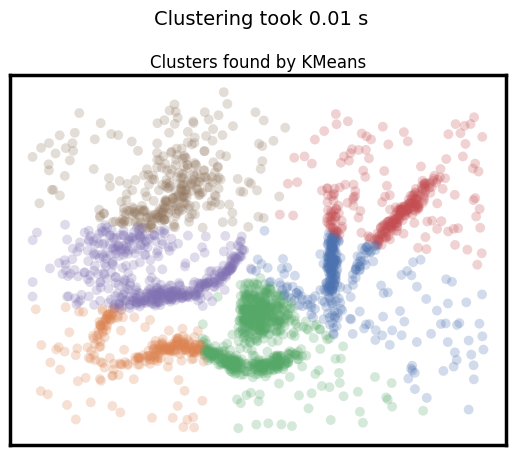

In [12]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'n_init':'auto', 'max_iter':600})

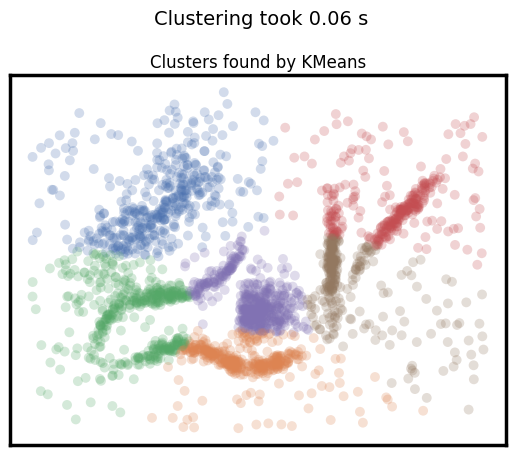

In [13]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6, 'init':'random', 'n_init':'auto', 'max_iter':600})

0.17213501363700578


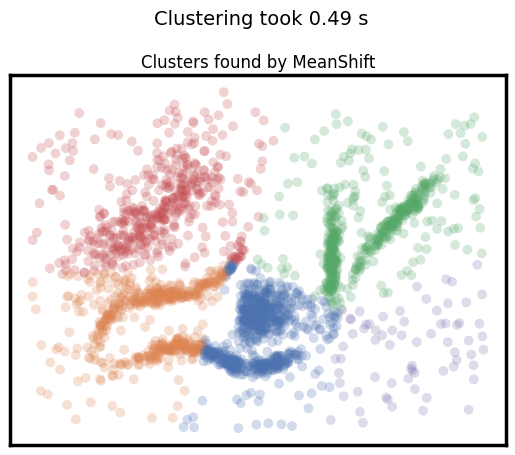

In [14]:
# to find the optimum bandwith
from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(data, quantile=0.3, n_samples=8)
print(bandwidth)
plot_clusters(data, cluster.MeanShift,(), {'bandwidth': bandwidth, 'bin_seeding':True})

0.17213501363700578


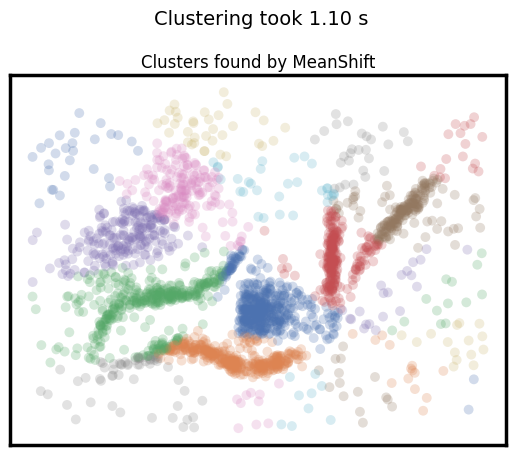

In [15]:

from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(data, quantile=0.3, n_samples=8)
print(bandwidth)
plot_clusters(data, cluster.MeanShift,(), {'bandwidth': 0.1, 'bin_seeding':True})

0.17213501363700578


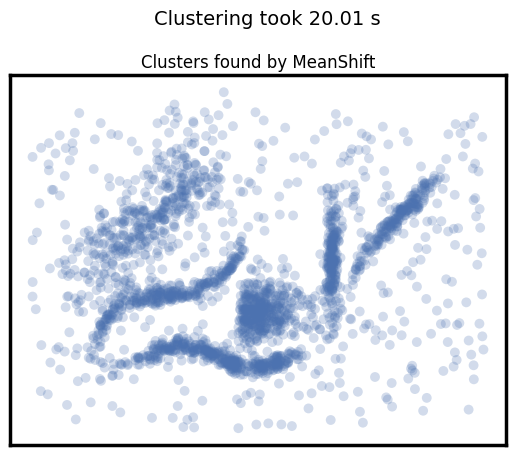

In [16]:
from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(data, quantile=0.3, n_samples=8)
print(bandwidth)
plot_clusters(data, cluster.MeanShift,(), {'bandwidth': 0.3, 'bin_seeding':False})

0.17213501363700578


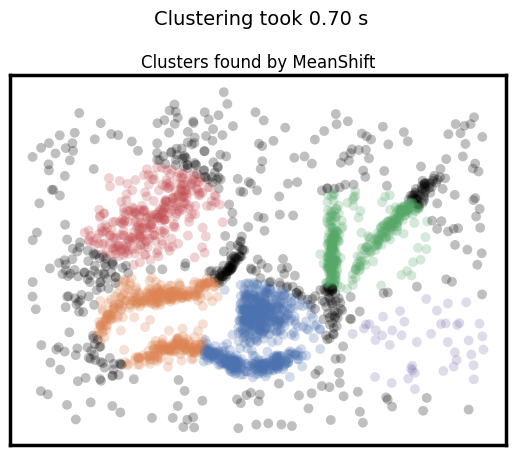

In [17]:
#optimal

from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(data, quantile=0.3, n_samples=8)
print(bandwidth)
plot_clusters(data, cluster.MeanShift,(), {'bandwidth': 0.18, 'bin_seeding':True, 'cluster_all':False})

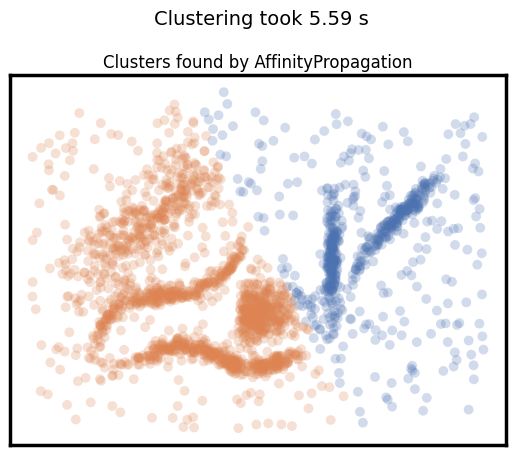

In [46]:
plot_clusters(data, cluster.AffinityPropagation,(), {'preference': -50, 'damping':0.9})

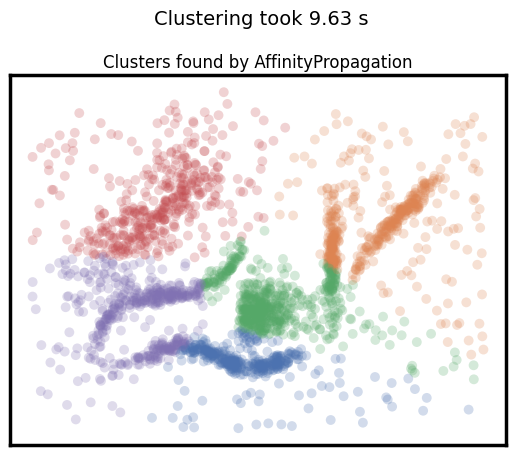

In [19]:
plot_clusters(data, cluster.AffinityPropagation,(), {'preference': -15, 'damping':0.9})

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_affinity_propagation.py:143: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


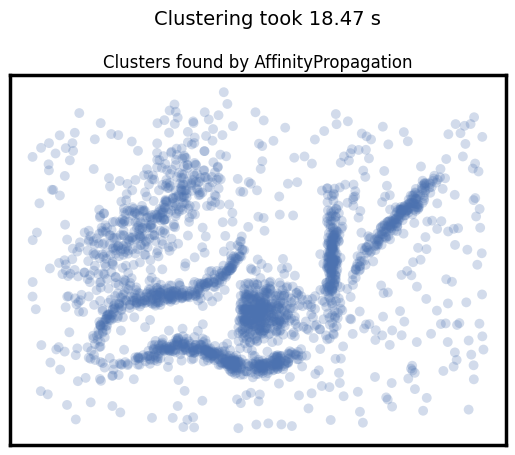

In [20]:
plot_clusters(data, cluster.AffinityPropagation,(), {'preference': -15, 'damping':0.5})

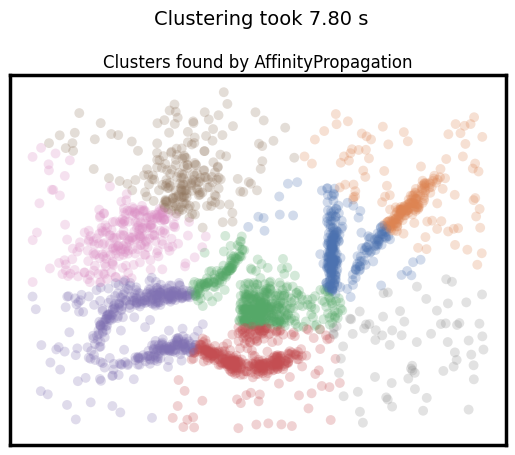

In [21]:
plot_clusters(data, cluster.AffinityPropagation,(), {'preference': -5.0, 'damping':0.9})

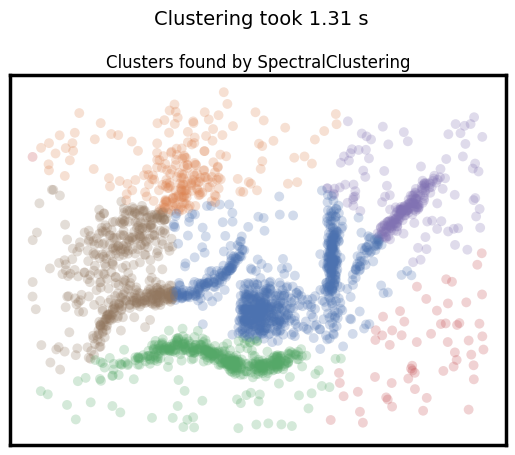

In [22]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'affinity':'rbf'})

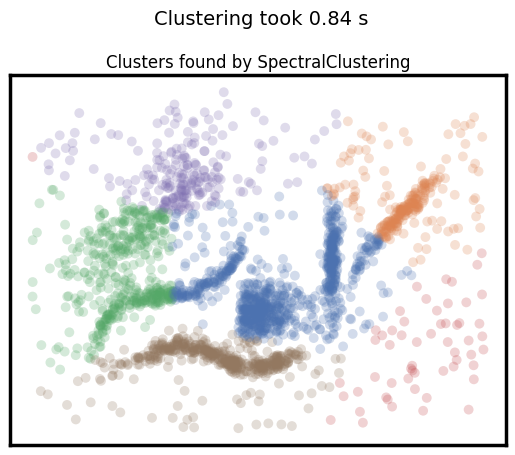

In [23]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'eigen_solver':'lobpcg', 'affinity':'rbf'})

In [24]:
pip install pyamg


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.3 MB/s eta 0:00:00


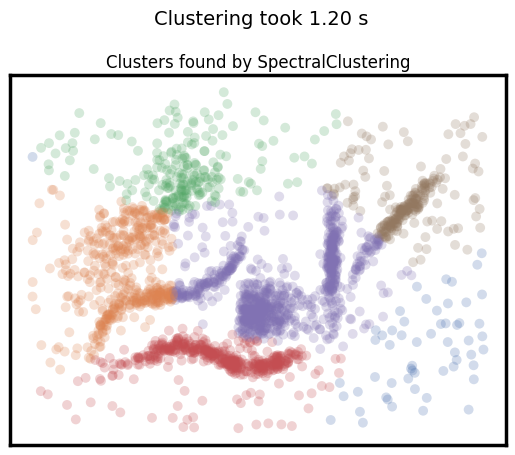

In [25]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'eigen_solver':'amg', 'affinity':'rbf'})

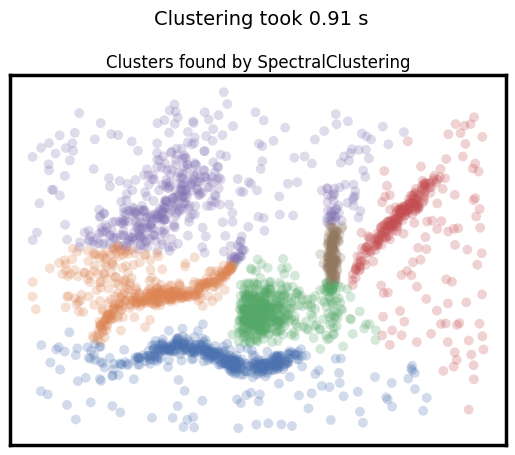

In [26]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'eigen_solver':'arpack', 'affinity':'nearest_neighbors'})

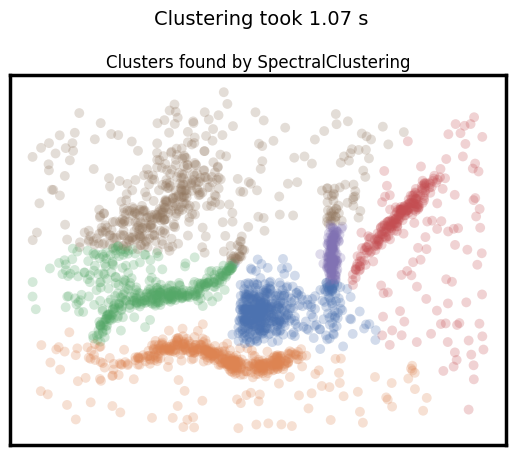

In [27]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'eigen_solver':'lobpcg', 'affinity':'nearest_neighbors'})

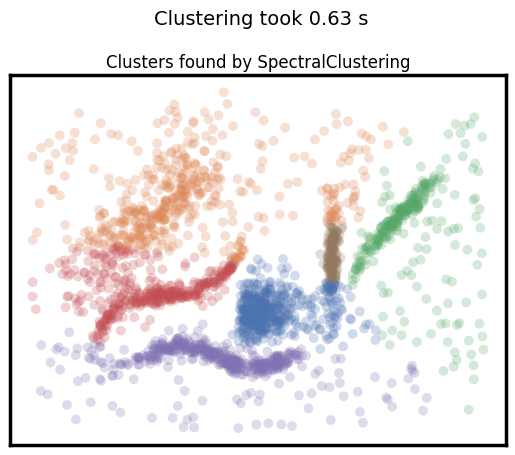

In [28]:
plot_clusters(data, cluster.SpectralClustering,(), {'n_clusters': 6, 'eigen_solver':'amg', 'affinity':'nearest_neighbors'})

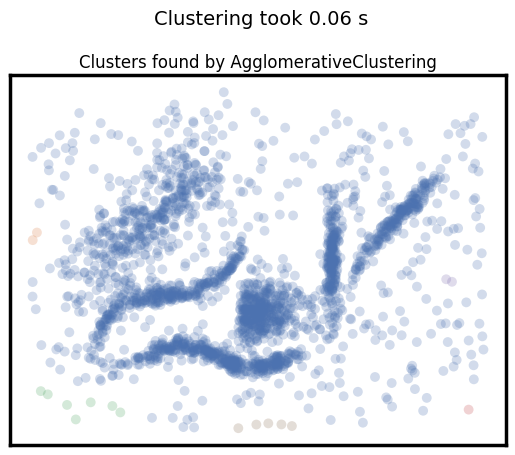

In [29]:
plot_clusters(data, cluster.AgglomerativeClustering,(), {'n_clusters': 6, 'linkage':'single'})

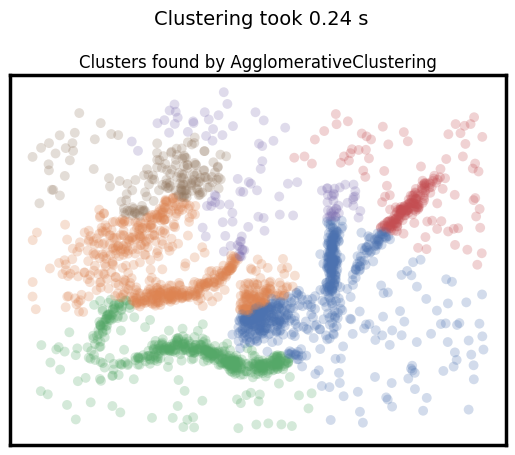

In [30]:
plot_clusters(data, cluster.AgglomerativeClustering,(), {'n_clusters': 6, 'linkage':'complete'})

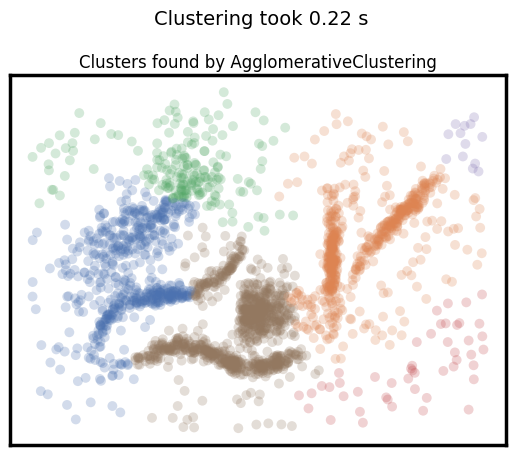

In [31]:
plot_clusters(data, cluster.AgglomerativeClustering,(), {'n_clusters': 6, 'linkage':'average'})

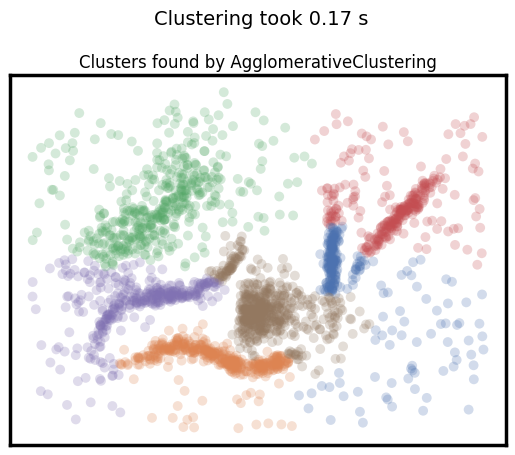

In [32]:
plot_clusters(data, cluster.AgglomerativeClustering,(), {'n_clusters': 6, 'linkage':'ward'})

In [33]:
pip install hdbscan

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 86.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hdbscan: filename=hdbscan-0.8.29-cp310-cp310-linux_x86_64.whl size=3541514 sha256=63bc6e049dd84ade7e14d0b0f8b8f65a6985eca65a2c1dbcf22a24df0879bd48
  Stored in directory: /root/.cache/pip/wheels/dc/52/e3/6c6b60b126b4d5c4370cb5ac071b82950f91649d62d72f7f56
Successfully built hdbscan


In [34]:
import hdbscan

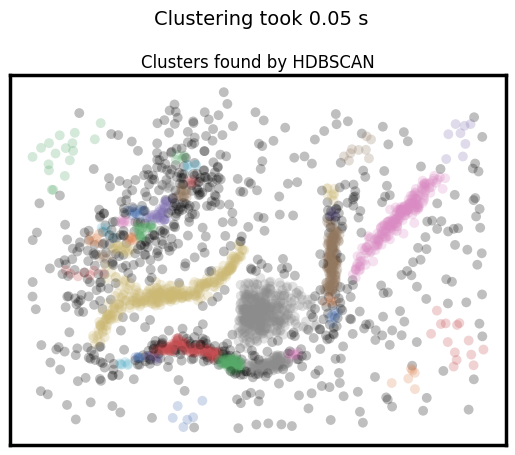

In [50]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':5})

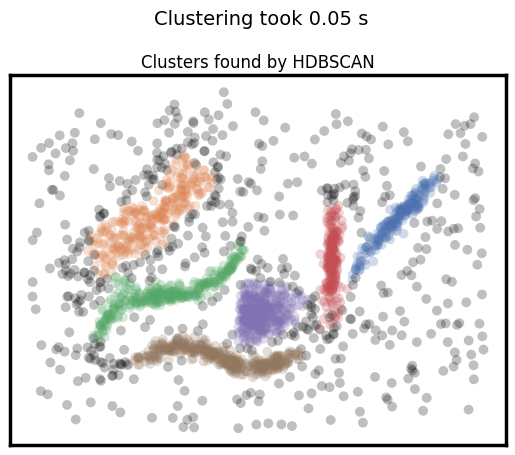

In [35]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':15})

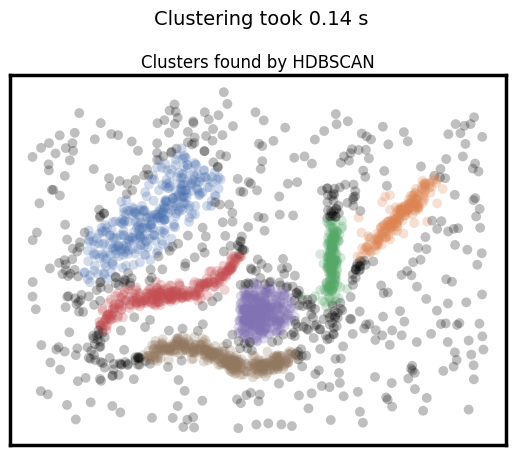

In [40]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':30})

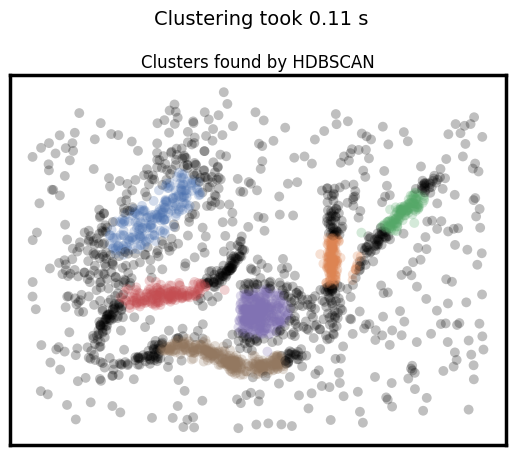

In [44]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':90})

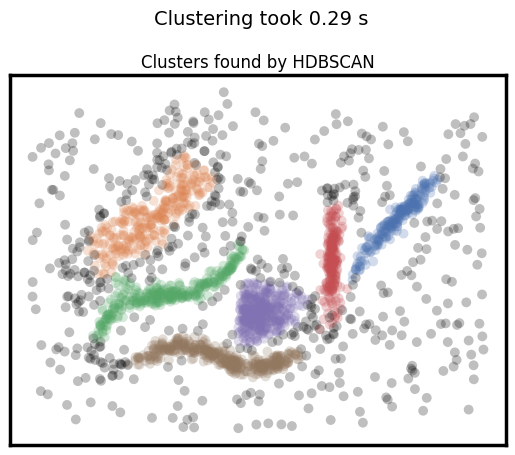

In [43]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':90, 'min_samples':15})

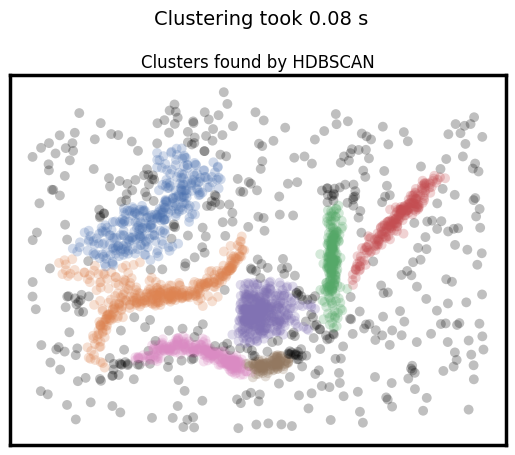

In [45]:
plot_clusters(data, hdbscan.HDBSCAN, (), {'min_cluster_size':90, 'min_samples':1})